 ### DATA UNDERSTANDING & PREPROCESSING

###  1. IMPORT LIBRARIES

In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

### 2. LOAD DATA

In [84]:
train = pd.read_csv('processed_train.csv')
test = pd.read_csv('processed_test.csv')

### 3. BASIC INFORMATION

In [85]:
train.head()

,Unnamed: 0,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,1,60,65.0,8450.0,5,7,5,2003,2003,...,False,False,False,True,False,False,False,False,True,False
1,1,2,20,80.0,9600.0,24,6,8,1976,1976,...,False,False,False,True,False,False,False,False,True,False
2,2,3,60,68.0,11250.0,5,7,5,2001,2002,...,False,False,False,True,False,False,False,False,True,False
3,3,4,70,60.0,9550.0,6,7,5,1915,1970,...,False,False,False,True,True,False,False,False,False,False
4,4,5,60,84.0,14260.0,15,8,5,2000,2000,...,False,False,False,True,False,False,False,False,True,False


In [86]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 235 entries, Unnamed: 0 to SaleCondition_Partial
dtypes: bool(193), float64(7), int64(35)
memory usage: 754.4 KB


In [87]:
train.describe()

,Unnamed: 0,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,730.500000,56.897260,69.090411,9647.388014,12.251370,6.099315,5.575342,1971.267808,1984.865753,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,421.610009,42.300571,17.231909,3594.356399,6.013735,1.382997,1.112799,30.202904,20.645407,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,0.000000,1.000000,20.000000,31.500000,1481.500000,0.000000,1.000000,1.000000,1872.000000,1950.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,364.750000,365.750000,20.000000,60.000000,7553.500000,7.000000,5.000000,5.000000,1954.000000,1967.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,729.500000,730.500000,50.000000,69.000000,9478.500000,12.000000,6.000000,5.000000,1973.000000,1994.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1094.250000,1095.250000,70.000000,79.000000,11601.500000,17.000000,7.000000,6.000000,2000.000000,2004.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1459.000000,1460.000000,190.000000,107.500000,17673.500000,24.000000,10.000000,9.000000,2010.000000,2010.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


###  4. CHECK MISSING VALUES

In [88]:
train.isnull().sum()
test.isnull().sum()

Unnamed: 0               0
Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 221, dtype: int64

### 5. HANDLE MISSING VALUES

### Numerical columns → fill with median

In [89]:

num_cols = train.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    if col in test.columns:
        test[col] = test[col].fillna(test[col].median())

num_cols

Index(['Unnamed: 0', 'Id', 'MSSubClass', 'LotFrontage', 'LotArea',
       'Neighborhood', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'Exterior1st', 'Exterior2nd', 'MasVnrArea',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

### Categorical columns → fill with mode

In [90]:
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mode()[0])
cat_cols

Index([], dtype='object')

### 6. ENCODING (Categorical → Numerical)

In [91]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le

LabelEncoder()

In [92]:
for col in cat_cols:
    train[col] = le.fit_transform(train[col])
    if col in test.columns:
        test[col] = le.fit_transform(test[col])

### 7. FINAL CHECK

In [93]:

print(f"\nAFTER CLEANING\n Missing Values Left (Train):\n{train.isnull().sum().sum()}\n\n Missing Values Left (Test):\n{test.isnull().sum().sum()}\n\n \nData Preprocessing Completed here")


AFTER CLEANING
 Missing Values Left (Train):
0

 Missing Values Left (Test):
0

 
Data Preprocessing Completed here


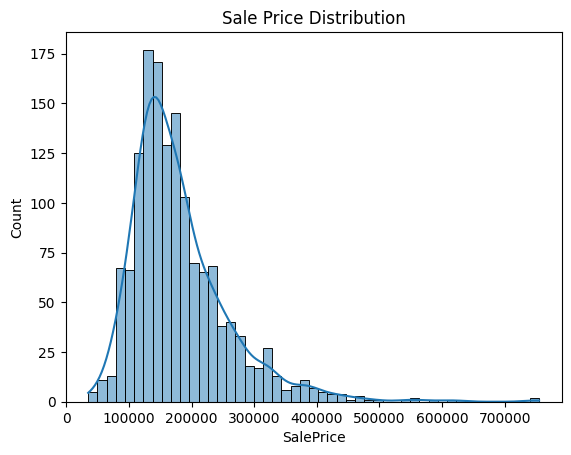

In [94]:
sns.histplot(train['SalePrice'], kde=True)
plt.title("Sale Price Distribution")
plt.show()

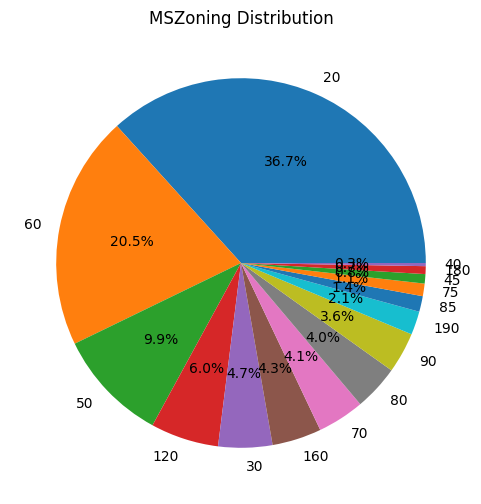

In [95]:
train['MSSubClass'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6)
)
plt.title("MSZoning Distribution")
plt.ylabel('')
plt.show()

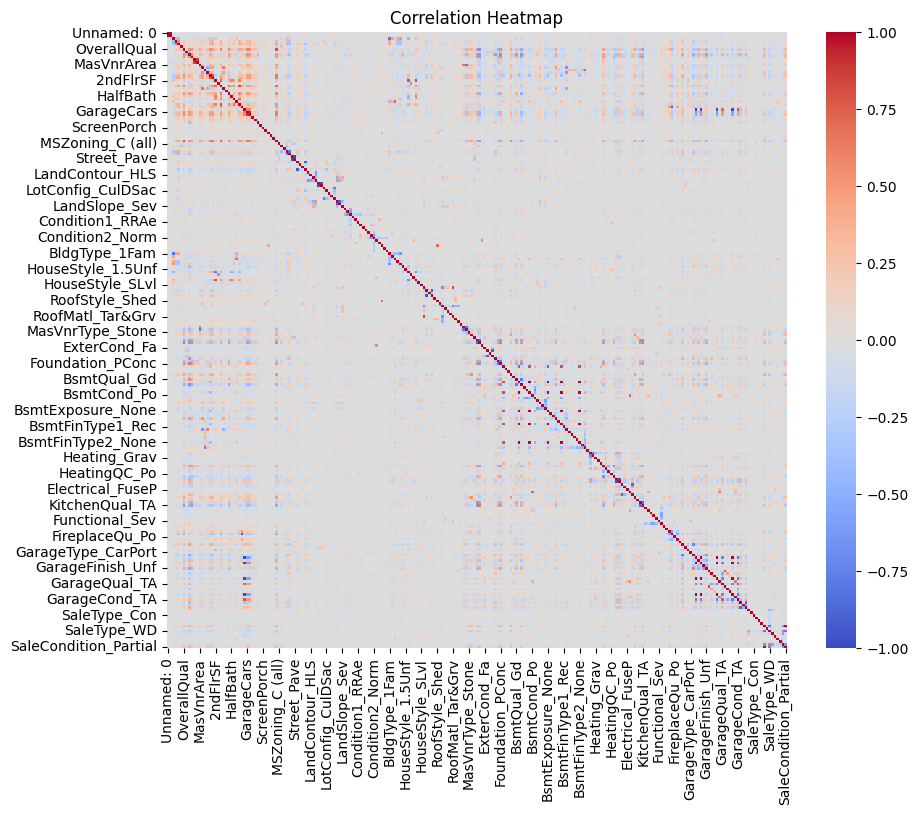

In [96]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### In this phase, we loaded the dataset, analyzed the data, handled missing values using the median and mode, and converted categorical data into numerical format.

### Model Building & Training

In [97]:
# 1. FEATURE & TARGET DEFINE
X = train.drop(['SalePrice'], axis=1)   # Features
y = train['SalePrice']                  # Target

print("Features Shape:", X.shape)


Features Shape: (1460, 234)


In [98]:
print("Target Shape:", y.shape)

Target Shape: (1460,)


In [99]:
# 2. TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)

Training Data: (1168, 234)
Validation Data: (292, 234)


In [100]:
# 3. MODEL SELECTION & TRAINING
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
)

In [101]:
# Train the model
model.fit(X_train, y_train)

print("\nModel Training Completed ")


Model Training Completed 


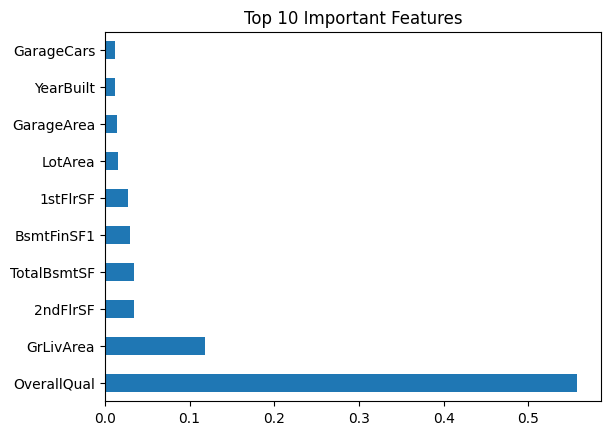

In [102]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

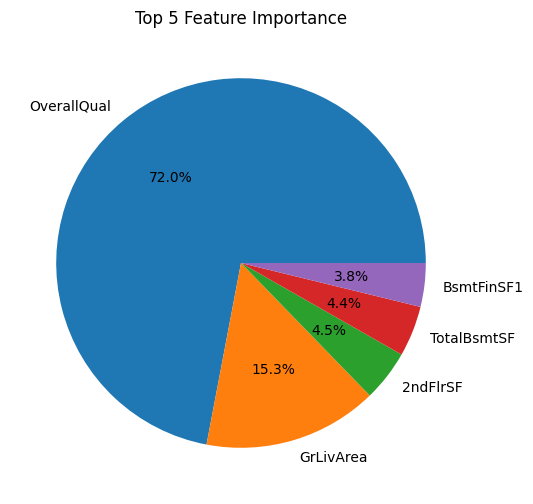

In [103]:
top5 = feat_imp.nlargest(5)

top5.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Top 5 Feature Importance")
plt.ylabel('')
plt.show()

### In this phase we separated the features and the target variable. Then we divided the data into training and validation sets. After that we trained the model using a Random Forest Regressor.


### To generalize the model we split the data so that we could evaluate its performance on the validation set.


### Evaluation + Prediction + Submission

In [104]:
# 1. VALIDATION PREDICTION
y_pred = model.predict(X_val)

In [105]:
# 2. MODEL EVALUATION
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("Model Evaluation Results:")


Model Evaluation Results:


In [106]:
print("RMSE:", rmse)


RMSE: 28619.42366009027


In [107]:
print("R2 Score:", r2)

R2 Score: 0.8932155701711537


In [108]:
# Combine datasets
train_len = train.shape[0]

full_data = pd.concat([train, test], axis=0)

In [109]:
# Fill missing values
for col in full_data.select_dtypes(include=['int64','float64']).columns:
    full_data[col] = full_data[col].fillna(full_data[col].median())

for col in full_data.select_dtypes(include=['object']).columns:
    full_data[col] = full_data[col].fillna(full_data[col].mode()[0])

C:\Users\alias\AppData\Local\Temp\ipykernel_10252\3986290714.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_data[col] = full_data[col].fillna(full_data[col].mode()[0])


In [110]:
full_data = pd.get_dummies(full_data)
full_data

,Unnamed: 0,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,1,60,65.0,8450.00,5,7,5,2003,2003,...,False,False,False,True,False,False,False,False,True,False
1,1,2,20,80.0,9600.00,24,6,8,1976,1976,...,False,False,False,True,False,False,False,False,True,False
2,2,3,60,68.0,11250.00,5,7,5,2001,2002,...,False,False,False,True,False,False,False,False,True,False
3,3,4,70,60.0,9550.00,6,7,5,1915,1970,...,False,False,False,True,True,False,False,False,False,False
4,4,5,60,84.0,14260.00,15,8,5,2000,2000,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,1454,2915,160,33.0,1936.00,10,4,7,1970,1970,...,False,False,False,True,False,False,False,False,True,False
1455,1455,2916,160,33.0,1894.00,10,4,5,1970,1970,...,False,False,False,True,True,False,False,False,False,False
1456,1456,2917,20,105.0,17707.25,11,5,7,1960,1996,...,False,False,False,True,True,False,False,False,False,False
1457,1457,2918,85,62.0,10441.00,11,5,5,1992,1992,...,False,False,False,True,False,False,False,False,True,False


In [111]:
train = full_data[:train_len]
test = full_data[train_len:]

In [112]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [113]:
# 3. TEST DATA PREDICTION
test_pred = model.predict(test)

In [114]:
print("Test shape:", test.shape)
print("Prediction shape:", len(test_pred))

Test shape: (1459, 235)
Prediction shape: 1459


In [115]:
# 4. CREATE SUBMISSION FILE
submission = pd.DataFrame({'Id': test['Id'],'SalePrice': test_pred})


In [116]:
# Save file
submission.to_csv('submission.csv', index=False)

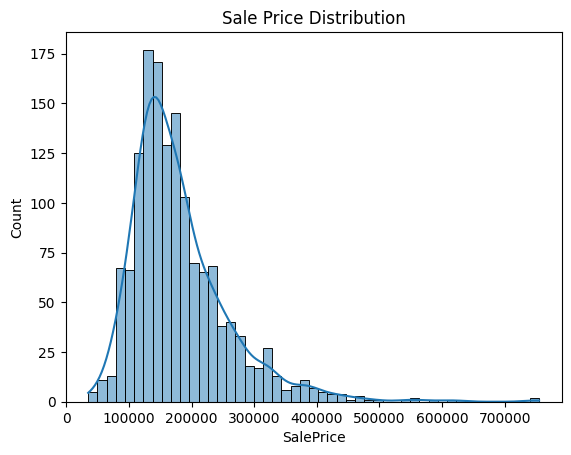

In [117]:
sns.histplot(train['SalePrice'], kde=True)
plt.title("Sale Price Distribution")
plt.show()

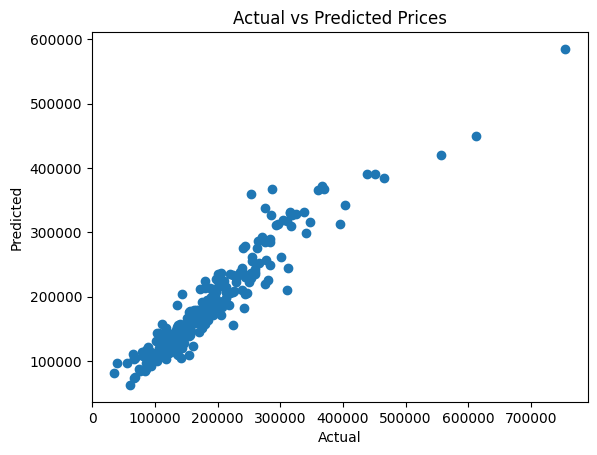

In [118]:
plt.scatter(y_val, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Prices")
plt.show()

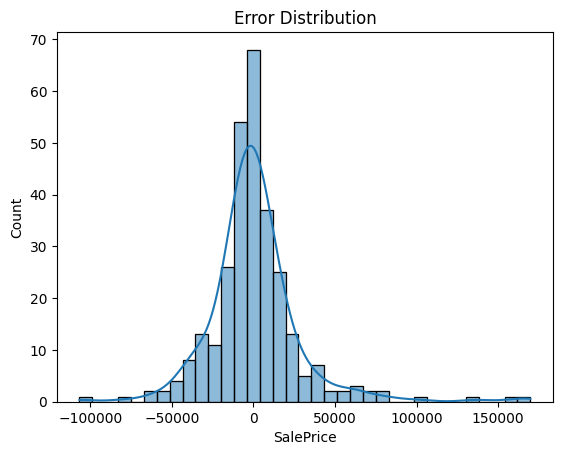

In [119]:
errors = y_val - y_pred

sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()

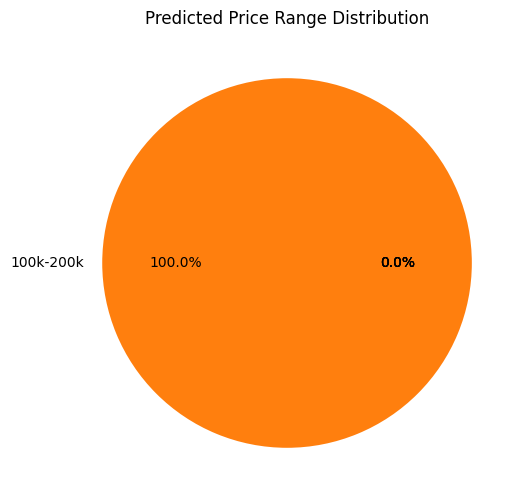

In [120]:
# Convert predictions into ranges
bins = [0, 100000, 200000, 300000, 500000, 1000000]
labels = ['0-100k', '100k-200k', '200k-300k', '300k-500k', '500k+']

test_pred_bins = pd.cut(test_pred, bins=bins, labels=labels)

test_pred_bins.value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6)
)

plt.title("Predicted Price Range Distribution")
plt.ylabel('')
plt.show()

### In this phase, we evaluated the models performance using RMSE and R² score. After that, we made predictions on the test data and generated the final submission file.


### We trained and validated the model, measured its performance, and generated predictions for real-world data.
